1. Create SMAC AC run

In [4]:
# define branin 
import numpy as np

def branin(x1, x2):
    a = 1.0
    b = 5.1 / (4 * np.pi**2)
    c = 5 / np.pi
    r = 6.0
    s = 10.0
    t = 1 / (8 * np.pi)

    return a * (x2 - b * x1**2 + c * x1 - r)**2 + s * (1 - t) * np.cos(x1) + s

In [8]:
from ConfigSpace import ConfigurationSpace, Configuration,Float
from smac import Scenario, AlgorithmConfigurationFacade
import numpy as np
import matplotlib.pyplot as plt

SEED = 0
N_TRIALS = 50

def branin_eval( config:Configuration, seed: int = 0):
    x1 = config["x1"]
    x2 = config["x2"]
    return branin(x1,x2)

cs = ConfigurationSpace(seed = SEED)
cs.add(
    Float("x1", bounds = (-5,10)),
    Float("x2", bounds = (0,15))
)

sc = Scenario(
    name = "branin",
    configspace = cs,
    deterministic = True,
    n_trials = N_TRIALS
)

smac_AC = AlgorithmConfigurationFacade(
    scenario = sc,
    target_function = branin_eval

)

incumbent = smac_AC.optimize()
print(incumbent)
print(smac_AC.runhistory.get_cost(incumbent))
print(smac_AC.runhistory.average_cost(incumbent))

[INFO][abstract_initial_design.py:91] Reducing the number of initial configurations from 20 to 12 (max_ratio == 0.25).
[INFO][abstract_initial_design.py:143] Using 1 initial design configurations and 0 additional configurations.
[INFO][smbo.py:523] Continuing from previous run.
[INFO][smbo.py:280] Optimization process was already finished. Returning incumbent...
Configuration(values={
  'x1': 9.025608383925,
  'x2': 3.3033425217732,
})
2.462570588140917
2.462570588140917


In [ ]:
from smac.runhistory.encoder import RunHistoryEncoder

RunHistoryEncoder()

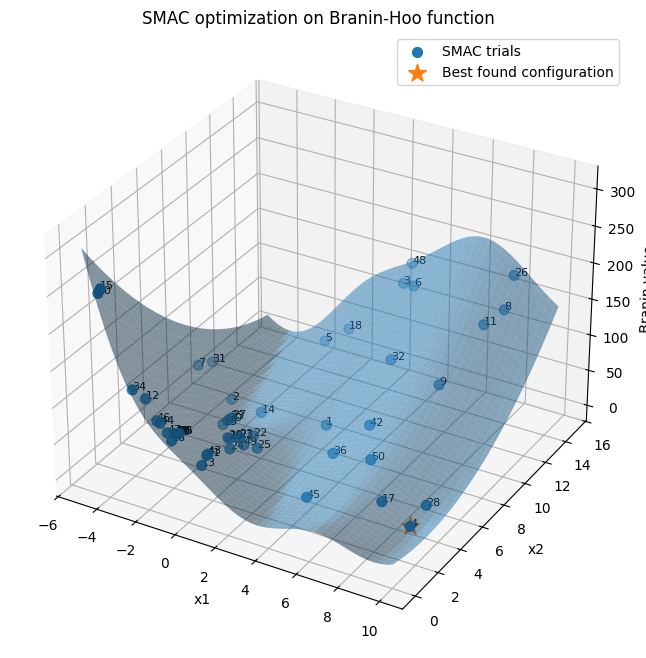

Best configuration:
{'x1': 9.025608383925, 'x2': 3.3033425217732}
Best cost: 2.462570588140917


In [10]:
# Create Branin surface
x1_grid = np.linspace(-5, 10, 100)
x2_grid = np.linspace(0, 15, 100)

X1, X2 = np.meshgrid(x1_grid, x2_grid)
Y = branin(X1, X2)


# Extract SMAC evaluated points
tried_x1 = []
tried_x2 = []
tried_y = []
trial_numbers = []

trials = []

for trial_key, trial_value in smac_AC.runhistory.items():
    config = smac_AC.runhistory.get_config(trial_key.config_id)

    trials.append({
        "x1": config["x1"],
        "x2": config["x2"],
        "cost": trial_value.cost,
        "starttime": trial_value.starttime,
    })

# Sort by evaluation time
trials = sorted(trials, key=lambda t: t["starttime"])

for i, trial in enumerate(trials, start=1):
    tried_x1.append(trial["x1"])
    tried_x2.append(trial["x2"])
    tried_y.append(trial["cost"])
    trial_numbers.append(i)


# Incumbent point
best_x1 = incumbent["x1"]
best_x2 = incumbent["x2"]
best_y = smac_AC.runhistory.get_cost(incumbent)


# 3D plot
fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(projection="3d")

# Surface
ax.plot_surface(X1, X2, Y, alpha=0.5)

# SMAC evaluated points
ax.scatter(
    tried_x1,
    tried_x2,
    tried_y,
    s=50,
    marker="o",
    label="SMAC trials",
)

# Best found point
ax.scatter(
    [best_x1],
    [best_x2],
    [best_y],
    s=180,
    marker="*",
    label="Best found configuration",
)

# Optional: annotate trial order
for i, x1, x2, y in zip(trial_numbers, tried_x1, tried_x2, tried_y):
    ax.text(x1, x2, y, str(i), fontsize=8)

ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("Branin value")
ax.set_title("SMAC optimization on Branin-Hoo function")
ax.legend()

plt.show()


print("Best configuration:")
print(dict(incumbent))
print("Best cost:", best_y)